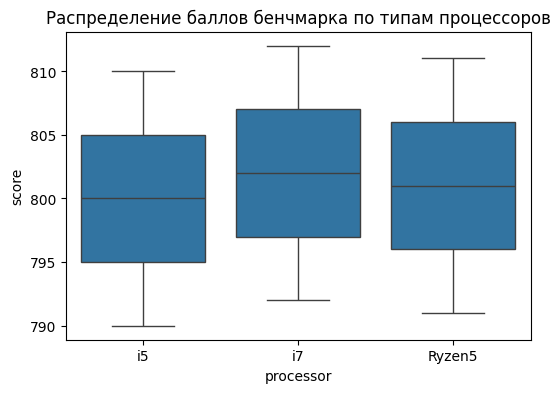

i5: p = 0.9672
i7: p = 0.9672
Ryzen5: p = 0.9672

Levene test: p = 1.0000

Таблица однофакторного дисперсионного анализа:
              sum_sq    df     F    PR(>F)
C(processor)    10.0   2.0  0.08  0.923604
Residual       750.0  12.0   NaN       NaN

Результат ANOVA незначим, пост-хок тест не требуется.


C:\Users\mokyb\AppData\Local\Temp\ipykernel_24096\1924649039.py:56: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_table['PR(>F)'][0] < 0.05:


In [3]:
# --- Задание 1 ---
# Однофакторный ANOVA: влияние типа процессора на бенчмарк

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Данные
data1 = {
    'processor': ['i5']*5 + ['i7']*5 + ['Ryzen5']*5,
    'score': [800, 810, 790, 805, 795,
              802, 812, 792, 807, 797,
              801, 811, 791, 806, 796]
}

df1 = pd.DataFrame(data1)

# 1. Визуализация данных
plt.figure(figsize=(6,4))
sns.boxplot(x='processor', y='score', data=df1)
plt.title('Распределение баллов бенчмарка по типам процессоров')
plt.show()

# Предварительное предположение:
# Судя по графику, различия между группами минимальные, возможно, статистически незначимые.

# 2. Проверка предпосылок ANOVA

# Нормальность в группах (тест Шапиро-Уилка)
for group in df1['processor'].unique():
    stat, p = stats.shapiro(df1[df1['processor']==group]['score'])
    print(f'{group}: p = {p:.4f}')

# Гомогенность дисперсий (тест Левена)
levene_stat, levene_p = stats.levene(
    df1[df1['processor']=='i5']['score'],
    df1[df1['processor']=='i7']['score'],
    df1[df1['processor']=='Ryzen5']['score']
)
print(f'\nLevene test: p = {levene_p:.4f}')

# Независимость — выполняется по условию эксперимента (разные измерения).

# 3. Однофакторный ANOVA
model = ols('score ~ C(processor)', data=df1).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print('\nТаблица однофакторного дисперсионного анализа:')
print(anova_table)

# 4. Пост-хок тест Тьюки HSD (если результат значим)
if anova_table['PR(>F)'][0] < 0.05:
    print('\nРезультат ANOVA значим, выполняем тест Тьюки HSD:')
    tukey = pairwise_tukeyhsd(df1['score'], df1['processor'], alpha=0.05)
    print(tukey)
else:
    print('\nРезультат ANOVA незначим, пост-хок тест не требуется.')

# 5. Интерпретация
# Если p > 0.05 — статистически значимых различий между типами процессоров нет.


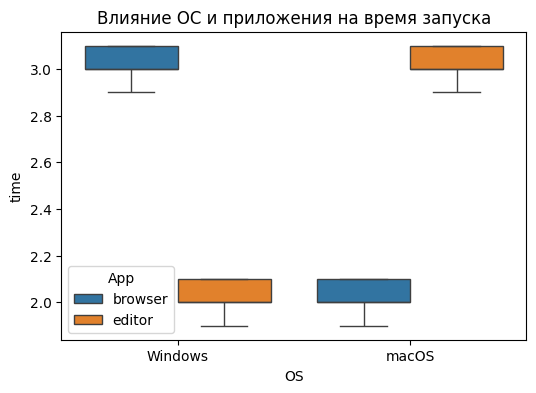

Windows + browser: p = 0.3140
Windows + editor: p = 0.3140
macOS + browser: p = 0.3140
macOS + editor: p = 0.3140

Levene test: p = 1.0000

Таблица двухфакторного дисперсионного анализа:
                    sum_sq    df             F        PR(>F)
C(OS)         2.055442e-31   1.0  2.936345e-29  1.000000e+00
C(App)        1.438666e-31   1.0  2.055237e-29  1.000000e+00
C(OS):C(App)  5.000000e+00   1.0  7.142857e+02  1.052901e-14
Residual      1.120000e-01  16.0           NaN           NaN


In [4]:
# --- Задание 2 ---
# Двухфакторный ANOVA: влияние ОС и приложения на время запуска

data2 = {
    'OS': ['Windows']*10 + ['macOS']*10,
    'App': ['browser']*5 + ['editor']*5 + ['browser']*5 + ['editor']*5,
    'time': [3.0, 3.1, 2.9, 3.0, 3.1,
             2.0, 2.1, 1.9, 2.0, 2.1,
             2.0, 2.1, 1.9, 2.0, 2.1,
             3.0, 3.1, 2.9, 3.0, 3.1]
}

df2 = pd.DataFrame(data2)

# 1. Визуализация данных
plt.figure(figsize=(6,4))
sns.boxplot(x='OS', y='time', hue='App', data=df2)
plt.title('Влияние ОС и приложения на время запуска')
plt.show()

# Предварительное предположение:
# Похоже, что приложения и ОС оказывают влияние: браузер и редактор меняют время запуска.

# 2. Проверка предпосылок ANOVA
# Нормальность в группах
for (os_, app), subset in df2.groupby(['OS', 'App']):
    stat, p = stats.shapiro(subset['time'])
    print(f'{os_} + {app}: p = {p:.4f}')

# Гомогенность дисперсий
levene_stat, levene_p = stats.levene(
    df2[(df2['OS']=='Windows') & (df2['App']=='browser')]['time'],
    df2[(df2['OS']=='Windows') & (df2['App']=='editor')]['time'],
    df2[(df2['OS']=='macOS') & (df2['App']=='browser')]['time'],
    df2[(df2['OS']=='macOS') & (df2['App']=='editor')]['time']
)
print(f'\nLevene test: p = {levene_p:.4f}')

# 3. Двухфакторный ANOVA
model2 = ols('time ~ C(OS) + C(App) + C(OS):C(App)', data=df2).fit()
anova_table2 = sm.stats.anova_lm(model2, typ=2)
print('\nТаблица двухфакторного дисперсионного анализа:')
print(anova_table2)

# 4. Интерпретация
# Если p < 0.05 у факторов — они оказывают значимое влияние на время запуска.
# Если значимо взаимодействие (C(OS):C(App)), то эффект одного фактора зависит от другого.
